In [1]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)

sns.set_theme()

In [2]:
os.chdir("/Users/felixdiederichs/PycharmProjects/Data_Analysis/.venv/Analyse/Heart")

data_resemblance = pd.read_csv('heart_resemblance.csv')
data_fairness = pd.read_csv('heart_fairness.csv')
data_utility = pd.read_csv('heart_utility.csv')

data_resemblance['id'] = range(len(data_resemblance))
data_fairness['id'] = range(len(data_fairness))
data_utility['id'] = range(len(data_utility))

data_merged = pd.merge(data_resemblance, data_fairness, on = 'id', how = 'left')
data_merged = pd.merge(data_merged, data_utility, on = 'id', how = 'left')

<Axes: xlabel='Epochs', ylabel='Average Statistical Parity Difference'>

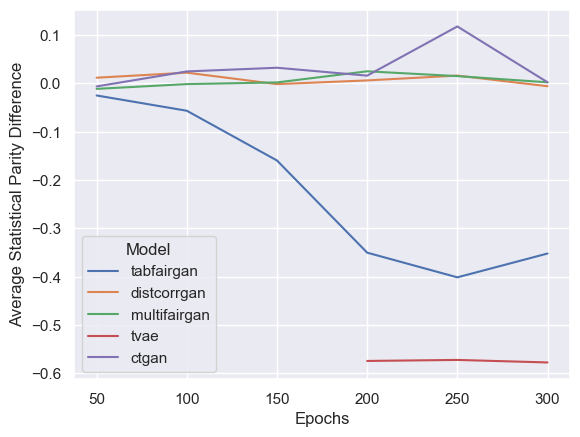

In [3]:
sns.lineplot(x = 'Epochs', y = 'Average Statistical Parity Difference', hue = 'Model', data = data_merged, errorbar=None)

<Axes: xlabel='Sorted Order', ylabel='Average Statistical Parity Difference'>

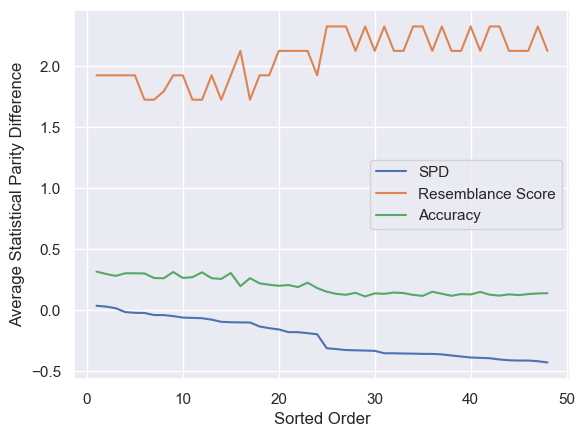

In [12]:
data_merged_tabfairgan = data_merged[data_merged['Model'] == 'tabfairgan']
data_merged_tabfairgan_sorted = data_merged_tabfairgan.sort_values('Average Statistical Parity Difference', ascending = False)
data_merged_tabfairgan_sorted['Sorted Order'] = range(1, len(data_merged_tabfairgan) + 1) 

sns.lineplot(x = 'Sorted Order', y = 'Average Statistical Parity Difference', data = data_merged_tabfairgan_sorted, label = 'SPD', errorbar=None)
sns.lineplot(x = 'Sorted Order', y = 'Overall Score', data = data_merged_tabfairgan_sorted, label = 'Resemblance Score',errorbar=None)
sns.lineplot(x = 'Sorted Order', y = 'Accuracy 1', data = data_merged_tabfairgan_sorted, label = 'Accuracy',errorbar=None)

<Axes: xlabel='Order Sorted', ylabel='Average Statistical Parity Difference'>

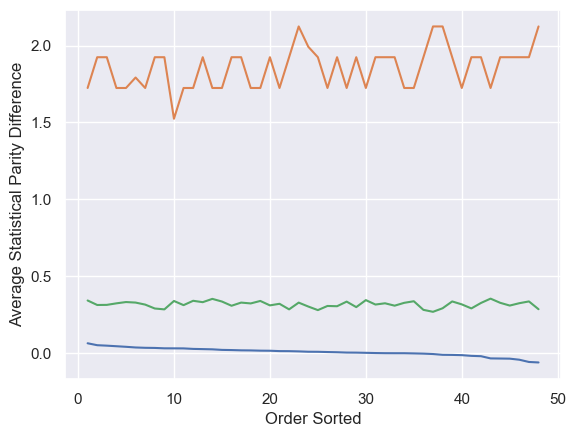

In [13]:
data_merged_distcorrgan = data_merged[data_merged['Model'] == 'distcorrgan']
data_merged_distcorrgan_sorted = data_merged_distcorrgan.sort_values('Average Statistical Parity Difference', ascending = False)
data_merged_distcorrgan_sorted['Order Sorted'] = range(1, len(data_merged_distcorrgan_sorted) + 1)

sns.lineplot(x = 'Order Sorted', y = 'Average Statistical Parity Difference', data = data_merged_distcorrgan_sorted, errorbar=None)
sns.lineplot(x = 'Order Sorted', y = 'Overall Score', data = data_merged_distcorrgan_sorted, errorbar=None)
sns.lineplot(x = 'Order Sorted', y = 'Accuracy 1', data = data_merged_distcorrgan_sorted, errorbar=None)

<Axes: xlabel='Order Sorted', ylabel='Average Statistical Parity Difference'>

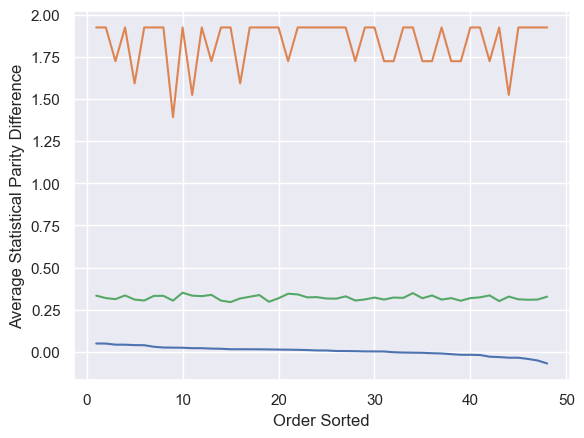

In [14]:
data_merged_multifairgan = data_merged[data_merged['Model'] == 'multifairgan']
data_merged_multifairgan_sorted = data_merged_multifairgan.sort_values('Average Statistical Parity Difference', ascending = False)
data_merged_multifairgan_sorted['Order Sorted'] = range(1, len(data_merged_multifairgan_sorted) + 1)

sns.lineplot(x = 'Order Sorted', y = 'Average Statistical Parity Difference', data = data_merged_multifairgan_sorted, errorbar=None)
sns.lineplot(x = 'Order Sorted', y = 'Overall Score', data = data_merged_multifairgan_sorted, errorbar=None)
sns.lineplot(x = 'Order Sorted', y = 'Accuracy 1', data = data_merged_multifairgan_sorted, errorbar=None)